# **CONCLUÍDO**

## <font color = 56A5EC>**Inicialização**

### <font color = FFB90F>**Instalações**

In [167]:
%pip install scikit-survival --quiet
%pip install seaborn --quiet
%pip install --upgrade lifelines --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### <font color = FFB90F>**Importações**

In [ ]:
%pip install scikit-survival --quiet

# === Visualização ===
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# === Manipulação de Dados ===
import numpy as np
import pandas as pd

# === Scikit-learn ===
# Pré-Processamento
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score)
from sksurv.metrics import integrated_brier_score, concordance_index_ipcw
from sksurv.util import Surv
set_config(display = "text")

# === Lifelines ===
# Modelagem e Estimações
from lifelines import CoxPHFitter, KaplanMeierFitter,       NelsonAalenFitter
from lifelines.statistics import proportional_hazard_test, multivariate_logrank_test
from lifelines.calibration import survival_probability_calibration

Note: you may need to restart the kernel to use updated packages.


## <font color = 56A5EC>**Carregamento dos Dados Tratados**

In [169]:
# Atribuição do Banco de Dados Original
df_colo = pd.read_csv('../DataSet/Colorretal_tratado_2025.csv', low_memory = False)

# Exibição
display(df_colo.head(3))
print(df_colo.shape)

,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,TOPO,ECGRUP,ANODIAG,HABILIT,nDRS,CONSDIAG_CAT,TRATCONS_CAT,DIAGTRAT_CAT,MORFO_CAT,time,event
0,9326,2,20,1,2,1,C182,IV,2019,1,9,2,2,0,Adenocarcinoma,33,1
1,12,4,20,2,9,2,C209,IV,2008,2,7,3,0,0,Adenocarcinoma,4,1
2,16624,5,20,2,2,2,C189,IV,2014,1,1,3,2,2,Adenocarcinoma,26,1


(32664, 17)


In [170]:
# Nome das coluas usadas em forma de lista
df_colo.columns.tolist()

['INSTITU',
 'ESCOLARI',
 'IDADE',
 'SEXO',
 'CATEATEND',
 'DIAGPREV',
 'TOPO',
 'ECGRUP',
 'ANODIAG',
 'HABILIT',
 'nDRS',
 'CONSDIAG_CAT',
 'TRATCONS_CAT',
 'DIAGTRAT_CAT',
 'MORFO_CAT',
 'time',
 'event']

In [171]:
# Visualização das colunas com o evento
df_colo['event'].value_counts().sort_index()

event
0    14524
1    18140
Name: count, dtype: int64

In [172]:
# Visualização da coluna tempo do evento
df_colo['time'].value_counts().sort_index()

time
1      1188
2      1007
3       884
4       812
5       714
      ...  
57      141
58      141
59      140
60      158
61    12412
Name: count, Length: 61, dtype: int64

In [173]:
# Total de Valores Censurados
censored_count = df_colo['event'].value_counts()[0]
print(f"Número de valores censurados: {censored_count}")

Número de valores censurados: 14524


## <font color = 56A5EC>**Treinamento e Teste**

### <font color = FFB90F>**Divisão**

In [192]:
X_train, X_test = train_test_split(
    df_colo,                             # Dataset completo
    test_size = 0.2,                     # 20% para teste
    stratify = df_colo['event'],         # Estratificar por status de evento
    random_state = 19                    # Seed para reprodutibilidade
) 

# Reset dos índices para evitar problemas posteriores
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

### <font color = FFB90F>**Verificação de Dimensionalidade**

In [189]:
# Verificação dos tamanhos dos conjuntos
print("="*80)
print("DIMENSIONALIDADE DOS CONJUNTOS")
print("="*80)
print(f"\nDataFrame Original Completo:")
print(f"  Tamanho: {df_colo.shape[0]:,} pacientes × {df_colo.shape[1]} variáveis")

print(f"\nConjunto de TREINAMENTO:")
print(f"  Tamanho: {X_train.shape[0]:,} pacientes ({X_train.shape[0]/df_colo.shape[0]*100:.1f}%)")
print(f"  Variáveis: {X_train.shape[1]}")

print(f"\nConjunto de TESTE:")
print(f"  Tamanho: {X_test.shape[0]:,} pacientes ({X_test.shape[0]/df_colo.shape[0]*100:.1f}%)")
print(f"  Variáveis: {X_test.shape[1]}")

total_recomb = X_train.shape[0] + X_test.shape[0]
check = "✓" if total_recomb == df_colo.shape[0] else "✗"
print(f"\nTOTAL RECOMBINADO: {total_recomb:,} (esperado: {df_colo.shape[0]:,}) {check}")
print("="*80)

DIMENSIONALIDADE DOS CONJUNTOS

DataFrame Original Completo:
  Tamanho: 32,664 pacientes × 17 variáveis

Conjunto de TREINAMENTO:
  Tamanho: 26,131 pacientes (80.0%)
  Variáveis: 17

Conjunto de TESTE:
  Tamanho: 6,533 pacientes (20.0%)
  Variáveis: 17

TOTAL RECOMBINADO: 32,664 (esperado: 32,664) ✓


### <font color = FFB90F>**Verificação de Balanceamento de Eventos**

In [190]:
# Análise da distribuição de eventos (mortes vs censura)
print("\n" + "="*80)
print("BALANCEAMENTO DE EVENTOS (Estratificação por 'event')")
print("="*80)

print(f"\nDataFrame Original:")
print(f"  Taxa de Eventos: {df_colo['event'].mean():.2%}")
for event_val, count in sorted(df_colo['event'].value_counts().items()):
    label = "Morte (event=1)" if event_val == 1 else "Censura (event=0)"
    pct = count / len(df_colo) * 100
    print(f"    {label}: {count:,} ({pct:.2f}%)")

print(f"\nConjunto de TREINAMENTO:")
print(f"  Taxa de Eventos: {X_train['event'].mean():.2%}")
for event_val, count in sorted(X_train['event'].value_counts().items()):
    label = "Morte (event=1)" if event_val == 1 else "Censura (event=0)"
    pct = count / len(X_train) * 100
    print(f"    {label}: {count:,} ({pct:.2f}%)")

print(f"\nConjunto de TESTE:")
print(f"  Taxa de Eventos: {X_test['event'].mean():.2%}")
for event_val, count in sorted(X_test['event'].value_counts().items()):
    label = "Morte (event=1)" if event_val == 1 else "Censura (event=0)"
    pct = count / len(X_test) * 100
    print(f"    {label}: {count:,} ({pct:.2f}%)")

# Verificação de balanceamento
diff = abs(X_train['event'].mean() - X_test['event'].mean())
status = "✓ EXCELENTE BALANCEAMENTO" if diff < 0.001 else "✓ BOM BALANCEAMENTO" if diff < 0.01 else "⚠ DESBALANCEAMENTO"
print(f"\nDiferença de Taxa de Eventos:")
print(f"  |Taxa_treino - Taxa_teste| = {diff:.6f}")
print(f"  Status: {status}")
print("="*80)


BALANCEAMENTO DE EVENTOS (Estratificação por 'event')

DataFrame Original:
  Taxa de Eventos: 55.54%
    Censura (event=0): 14,524 (44.46%)
    Morte (event=1): 18,140 (55.54%)

Conjunto de TREINAMENTO:
  Taxa de Eventos: 55.54%
    Censura (event=0): 11,619 (44.46%)
    Morte (event=1): 14,512 (55.54%)

Conjunto de TESTE:
  Taxa de Eventos: 55.53%
    Censura (event=0): 2,905 (44.47%)
    Morte (event=1): 3,628 (55.53%)

Diferença de Taxa de Eventos:
  |Taxa_treino - Taxa_teste| = 0.000021
  Status: ✓ EXCELENTE BALANCEAMENTO


## <font color = 56A5EC>**Codificação das Colunas**

### <font color = FFB90F>**Identificações**

In [175]:
# Identificação das colunas categóricas
categorical_cols = df_colo.select_dtypes(include = ['object', 'category']).columns.tolist()
print("Colunas Categóricas:", categorical_cols)

Colunas Categóricas: ['TOPO', 'ECGRUP', 'MORFO_CAT']


In [176]:
# Identificação de colunas booleanas
boolean_cols = [col for col in df_colo.columns if df_colo[col].dtype ==bool]
print("Colunas com valores booleanos:", boolean_cols)

Colunas com valores booleanos: []


### <font color = FFB90F>**Codificação**

In [177]:
def encoding(df_train, df_test, ordinal_col = "ECGRUP", ordinal_order = ("I", "II", "III", "IV"), 
             onehot_cols = ("TOPO", "MORFO_CAT"), drop_first = True):
    """
    Descrição:
      Codifica colunas categóricas para ambos os conjuntos (treino e teste).
      **IMPORTANTE:** Os encoders são fitted APENAS no conjunto de treino,
      depois aplicados a ambos para evitar data leakage.
      
      - OrdinalEncoder: ECGRUP (ordem I < II < III < IV)
      - OneHotEncoder: TOPO e MORFO_CAT

    Parâmetros:
      df_train: DataFrame de treinamento (usado para FIT dos encoders)
      df_test: DataFrame de teste (usado apenas para TRANSFORM)
      ordinal_col: coluna ordinal a codificar
      ordinal_order: ordem das categorias ordinais
      onehot_cols: colunas para one-hot encoding
      drop_first: se True, remove primeira coluna do one-hot

    Retorno:
      X_train_encoded: DataFrame treino codificado
      X_test_encoded: DataFrame teste codificado
      encoders: dict com os encoders fitted (ordinal e onehot)
    """

    # =============== #
    # === ORDINAL === #
    # =============== #

    # Cria o OrdinalEncoder
    oe = OrdinalEncoder(
        categories = [list(ordinal_order)],
        handle_unknown = "use_encoded_value",
        unknown_value = -1
    )

    # Fit no TREINO apenas
    oe.fit(df_train[[ordinal_col]])

    # =============== #
    # === ONE-HOT === #
    # =============== #

    # Cria o OneHotEncoder
    ohe = OneHotEncoder(
        handle_unknown = "ignore",
        drop = "first" if drop_first else None,
        sparse_output = False
    )

    # Fit no TREINO apenas
    ohe.fit(df_train[list(onehot_cols)])

    # ========================= #
    # === APLICAÇÃO TREINO === #
    # ========================= #
    
    df_train_aux = df_train.copy().reset_index(drop=True)
    
    # Transform ordinal
    df_train_aux[[ordinal_col]] = oe.transform(df_train_aux[[ordinal_col]])
    
    # Transform one-hot
    X_ohe_train = ohe.transform(df_train_aux[list(onehot_cols)])
    ohe_cols = ohe.get_feature_names_out(list(onehot_cols))
    df_ohe_train = pd.DataFrame(X_ohe_train, columns=ohe_cols, index=df_train_aux.index)
    
    df_train_aux = df_train_aux.drop(columns=list(onehot_cols))
    X_train_encoded = pd.concat([df_train_aux, df_ohe_train], axis=1)

    # ======================== #
    # === APLICAÇÃO TESTE === #
    # ======================== #
    
    df_test_aux = df_test.copy().reset_index(drop=True)
    
    # Transform ordinal
    df_test_aux[[ordinal_col]] = oe.transform(df_test_aux[[ordinal_col]])
    
    # Transform one-hot
    X_ohe_test = ohe.transform(df_test_aux[list(onehot_cols)])
    df_ohe_test = pd.DataFrame(X_ohe_test, columns=ohe_cols, index=df_test_aux.index)
    
    df_test_aux = df_test_aux.drop(columns=list(onehot_cols))
    X_test_encoded = pd.concat([df_test_aux, df_ohe_test], axis=1)

    # ===================== #
    # === NaN's + Bools === #
    # ===================== #

    for df_enc in [X_train_encoded, X_test_encoded]:
        # Localização de colunas que possuem NaN's
        na_cols = df_enc.columns[df_enc.isna().any()].tolist()
        if len(na_cols) > 0:
            print("Aviso: colunas com NaN detectadas:", na_cols)

        # Converte bool -> int
        for c in df_enc.columns:
            if df_enc[c].dtype == "bool":
                df_enc[c] = df_enc[c].astype(int)

    # Encoders retornados
    encoders = {"ordinal": oe, "onehot": ohe}

    return X_train_encoded, X_test_encoded, encoders

In [178]:
# Aplicação - Encoders fitted APENAS no conjunto de treinamento
X_train_encoded, X_test_encoded, encoders = encoding(
    df_train = X_train,
    df_test = X_test,
    ordinal_col = "ECGRUP",
    ordinal_order = ("I", "II", "III", "IV"),
    onehot_cols = ("TOPO", "MORFO_CAT"),
    drop_first = True
)

# Exibição - Treinamento
print("CONJUNTO DE TREINAMENTO (Encoders fitted aqui):")
display(X_train_encoded.head())
print(f"Shape: {X_train_encoded.shape}\n")

# Exibição - Teste
print("CONJUNTO DE TESTE (Encoders aplicados aqui):")
display(X_test_encoded.head())
print(f"Shape: {X_test_encoded.shape}")

CONJUNTO DE TREINAMENTO (Encoders fitted aqui):


,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,ECGRUP,ANODIAG,HABILIT,nDRS,...,TOPO_C185,TOPO_C186,TOPO_C187,TOPO_C188,TOPO_C189,TOPO_C199,TOPO_C209,MORFO_CAT_Anel de sinete,MORFO_CAT_Indiferenciado,MORFO_CAT_Mucinoso
0,21636,2,68,2,2,1,1.0,2017,1,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,18600,9,38,2,9,1,2.0,2001,1,4,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,612374,3,57,2,9,2,3.0,2011,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,20737,4,48,1,9,2,1.0,2011,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,19488,3,62,1,2,1,2.0,2013,0,16,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Shape: (26131, 29)

CONJUNTO DE TESTE (Encoders aplicados aqui):


,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,ECGRUP,ANODIAG,HABILIT,nDRS,...,TOPO_C185,TOPO_C186,TOPO_C187,TOPO_C188,TOPO_C189,TOPO_C199,TOPO_C209,MORFO_CAT_Anel de sinete,MORFO_CAT_Indiferenciado,MORFO_CAT_Mucinoso
0,9385,9,75,2,9,1,1.0,2000,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,21636,2,24,1,9,2,1.0,2004,1,16,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,20737,2,48,1,9,1,0.0,2006,1,5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,21156,2,67,1,2,1,3.0,2018,2,13,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,21199,3,72,2,2,1,3.0,2015,0,13,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


Shape: (6533, 29)


### <font color = FFB90F>**Comparações**

In [179]:
# Colunas originais vs Colunas codificadas

print("Colunas Originais:")
display(df_colo.columns.tolist())

print("\nColunas após Encoder (Treinamento):")
display(X_train_encoded.columns.tolist())

print("\nColunas após Encoder (Teste) - IDÊNTICAS ao treinamento:")
display(X_test_encoded.columns.tolist())

Colunas Originais:


['INSTITU',
 'ESCOLARI',
 'IDADE',
 'SEXO',
 'CATEATEND',
 'DIAGPREV',
 'TOPO',
 'ECGRUP',
 'ANODIAG',
 'HABILIT',
 'nDRS',
 'CONSDIAG_CAT',
 'TRATCONS_CAT',
 'DIAGTRAT_CAT',
 'MORFO_CAT',
 'time',
 'event']


Colunas após Encoder (Treinamento):


['INSTITU',
 'ESCOLARI',
 'IDADE',
 'SEXO',
 'CATEATEND',
 'DIAGPREV',
 'ECGRUP',
 'ANODIAG',
 'HABILIT',
 'nDRS',
 'CONSDIAG_CAT',
 'TRATCONS_CAT',
 'DIAGTRAT_CAT',
 'time',
 'event',
 'TOPO_C181',
 'TOPO_C182',
 'TOPO_C183',
 'TOPO_C184',
 'TOPO_C185',
 'TOPO_C186',
 'TOPO_C187',
 'TOPO_C188',
 'TOPO_C189',
 'TOPO_C199',
 'TOPO_C209',
 'MORFO_CAT_Anel de sinete',
 'MORFO_CAT_Indiferenciado',
 'MORFO_CAT_Mucinoso']


Colunas após Encoder (Teste) - IDÊNTICAS ao treinamento:


['INSTITU',
 'ESCOLARI',
 'IDADE',
 'SEXO',
 'CATEATEND',
 'DIAGPREV',
 'ECGRUP',
 'ANODIAG',
 'HABILIT',
 'nDRS',
 'CONSDIAG_CAT',
 'TRATCONS_CAT',
 'DIAGTRAT_CAT',
 'time',
 'event',
 'TOPO_C181',
 'TOPO_C182',
 'TOPO_C183',
 'TOPO_C184',
 'TOPO_C185',
 'TOPO_C186',
 'TOPO_C187',
 'TOPO_C188',
 'TOPO_C189',
 'TOPO_C199',
 'TOPO_C209',
 'MORFO_CAT_Anel de sinete',
 'MORFO_CAT_Indiferenciado',
 'MORFO_CAT_Mucinoso']

In [180]:
# Tamanho original vs Tamanho codificado

print("Formato do DataFrame Original Completo:")
print(f"  df_colo: {df_colo.shape}")

print("\nFormatter do DataFrame após DIVISÃO (antes da codificação):")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

print("\nFormato do DataFrame após ENCODER (codificado):")
print(f"  X_train_encoded: {X_train_encoded.shape}")
print(f"  X_test_encoded:  {X_test_encoded.shape}")

print(f"\n[VERIFICAÇÃO] Total: {X_train_encoded.shape[0]} + {X_test_encoded.shape[0]} = {X_train_encoded.shape[0] + X_test_encoded.shape[0]} (esperado: {df_colo.shape[0]})")

Formato do DataFrame Original Completo:
  df_colo: (32664, 17)

Formatter do DataFrame após DIVISÃO (antes da codificação):
  X_train: (26131, 17)
  X_test:  (6533, 17)

Formato do DataFrame após ENCODER (codificado):
  X_train_encoded: (26131, 29)
  X_test_encoded:  (6533, 29)

[VERIFICAÇÃO] Total: 26131 + 6533 = 32664 (esperado: 32664)


In [181]:
# DataFrame original vs DataFrame codificado

print("CONJUNTO DE TREINAMENTO - Original:")
display(X_train.head())

print("\nCONJUNTO DE TREINAMENTO - Codificado:")
display(X_train_encoded.head())

print("\n" + "="*80)

print("CONJUNTO DE TESTE - Original:")
display(X_test.head())

print("\nCONJUNTO DE TESTE - Codificado:")
display(X_test_encoded.head())

CONJUNTO DE TREINAMENTO - Original:


,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,TOPO,ECGRUP,ANODIAG,HABILIT,nDRS,CONSDIAG_CAT,TRATCONS_CAT,DIAGTRAT_CAT,MORFO_CAT,time,event
0,21636,2,68,2,2,1,C181,II,2017,1,6,0,0,0,Mucinoso,2,1
1,18600,9,38,2,9,1,C186,III,2001,1,4,0,0,0,Adenocarcinoma,15,1
2,612374,3,57,2,9,2,C209,IV,2011,1,1,3,0,1,Adenocarcinoma,19,1
3,20737,4,48,1,9,2,C209,II,2011,1,2,3,0,2,Adenocarcinoma,61,0
4,19488,3,62,1,2,1,C188,III,2013,0,16,0,0,0,Adenocarcinoma,61,0



CONJUNTO DE TREINAMENTO - Codificado:


,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,ECGRUP,ANODIAG,HABILIT,nDRS,...,TOPO_C185,TOPO_C186,TOPO_C187,TOPO_C188,TOPO_C189,TOPO_C199,TOPO_C209,MORFO_CAT_Anel de sinete,MORFO_CAT_Indiferenciado,MORFO_CAT_Mucinoso
0,21636,2,68,2,2,1,1.0,2017,1,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,18600,9,38,2,9,1,2.0,2001,1,4,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,612374,3,57,2,9,2,3.0,2011,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,20737,4,48,1,9,2,1.0,2011,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,19488,3,62,1,2,1,2.0,2013,0,16,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0



CONJUNTO DE TESTE - Original:


,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,TOPO,ECGRUP,ANODIAG,HABILIT,nDRS,CONSDIAG_CAT,TRATCONS_CAT,DIAGTRAT_CAT,MORFO_CAT,time,event
0,9385,9,75,2,9,1,C189,II,2000,0,1,0,0,0,Adenocarcinoma,1,0
1,21636,2,24,1,9,2,C209,II,2004,1,16,3,0,1,Adenocarcinoma,23,1
2,20737,2,48,1,9,1,C209,I,2006,1,5,2,2,1,Adenocarcinoma,35,1
3,21156,2,67,1,2,1,C187,IV,2018,2,13,0,0,0,Adenocarcinoma,13,1
4,21199,3,72,2,2,1,C189,IV,2015,0,13,0,0,0,Adenocarcinoma,10,1



CONJUNTO DE TESTE - Codificado:


,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,ECGRUP,ANODIAG,HABILIT,nDRS,...,TOPO_C185,TOPO_C186,TOPO_C187,TOPO_C188,TOPO_C189,TOPO_C199,TOPO_C209,MORFO_CAT_Anel de sinete,MORFO_CAT_Indiferenciado,MORFO_CAT_Mucinoso
0,9385,9,75,2,9,1,1.0,2000,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,21636,2,24,1,9,2,1.0,2004,1,16,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,20737,2,48,1,9,1,0.0,2006,1,5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,21156,2,67,1,2,1,3.0,2018,2,13,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,21199,3,72,2,2,1,3.0,2015,0,13,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## <font color = 56A5EC>**FIT**


In [182]:
# Definição das colunas estratificadas
strata_cols = ['DIAGPREV', 'TRATCONS_CAT', 'CONSDIAG_CAT']

# Criação do modelo Cox com penalizador baixo para ajudar na convergência
cph = CoxPHFitter(penalizer = 0.01)

# Fit do modelo APENAS com dados de TREINAMENTO
cph.fit(
    X_train_encoded,          # DataFrame TREINAMENTO codificado
    duration_col = 'time',    # Coluna de tempo de sobrevivência
    event_col = 'event',      # Coluna de evento de sobrevivência
    strata = strata_cols      # Colunas estratificadas
)

print("Modelo treinado APENAS com dados de treinamento (80% dos dados)")

Modelo treinado APENAS com dados de treinamento (80% dos dados)


In [183]:
# Exibir o sumário do modelo ajustado
cph.print_summary()

model,lifelines.CoxPHFitter
duration col,'time'
event col,'event'
penalizer,0.01
l1 ratio,0.0
strata,"[DIAGPREV, TRATCONS_CAT, CONSDIAG_CAT]"
baseline estimation,breslow
number of observations,26131
number of events observed,14512
partial log-likelihood,-108115.74
time fit was run,2026-03-15 23:39:36 UTC


### <font color = FFB90F>**Gráfico e Métricas**</font>

O Gráfico avalia se a probabilidade <font color = #888B90>**prevista**</font> de sobreviver até 60 meses está alinhada com a <font color = #FF7F50>**observada**</font>.

- <font color = #888B90>**Eixo X:**</font>
Probabilidade prevista de morte até 60 meses

- <font color = #FF7F50>**Eixo Y:**</font>
Probabilidade observada de morte até 60 meses

- <font color = #9E7BFF>**Linha tracejada (45°):**</font>
Calibração perfeita

- <font color = #F54927>**Linha vermelha:**</font>
curva de calibração suavizada

- <font color = #488AC7>**Área azul:**</font>
distribuição das probabilidades previstas

- <font color = #FBE7A1>Quanto mais próxima da diagonal, melhor calibrado</font>

---
As Métricas analisadas são:

- ICI - Integrated Calibration Index

    <font color = #FBE7A1>Mede o erro médio absoluto da calibração

- E50

    <font color = #FBE7A1>Erro absoluto mediano

CALIBRAÇÃO DO MODELO - Probabilidade de Sobrevivência em 60 meses

CALIBRAÇÃO NO CONJUNTO DE TREINAMENTO:
--------------------------------------------------------------------------------
ICI =  0.015005686379433546
E50 =  0.01612039084086281


CALIBRAÇÃO NO CONJUNTO DE TESTE (Avaliação Honesta):
--------------------------------------------------------------------------------
ICI =  0.013863328686435682
E50 =  0.015117733801973232


(<Axes: title={'center': 'Smoothed calibration curve of \npredicted vs observed probabilities of t ≤ 60 mortality'}, xlabel='Predicted probability of \nt ≤ 60 mortality', ylabel='Observed probability of \nt ≤ 60 mortality'>,
 np.float64(0.013863328686435682),
 np.float64(0.015117733801973232))

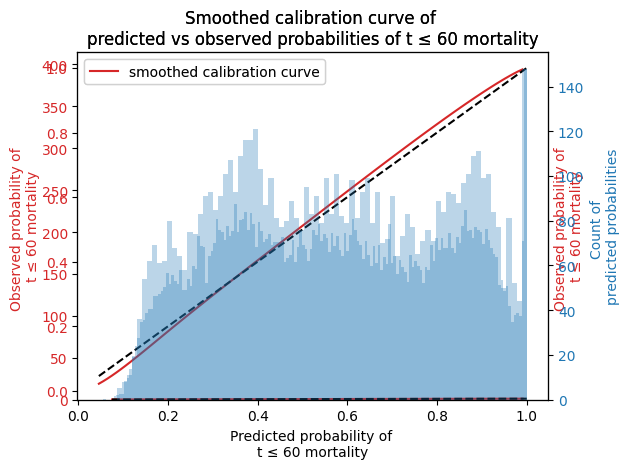

In [184]:
print("="*80)
print("CALIBRAÇÃO DO MODELO - Probabilidade de Sobrevivência em 60 meses")
print("="*80)

print("\nCALIBRAÇÃO NO CONJUNTO DE TREINAMENTO:")
print("-"*80)
survival_probability_calibration(
    cph,           # Modelo CoxPHFitter ajustado COM dados de treinamento
    X_train_encoded,  # Banco de Dados de TREINAMENTO
    t0 = 60        # Horizonte de 60 meses
)

print("\n" + "="*80)
print("\nCALIBRAÇÃO NO CONJUNTO DE TESTE (Avaliação Honesta):")
print("-"*80)
survival_probability_calibration(
    cph,           # Mesmo modelo
    X_test_encoded,   # Banco de Dados de TESTE (dados não vistos durante o fit)
    t0 = 60        # Horizonte de 60 meses
)

## <font color = 56A5EC>**Validação do Modelo**

### <font color = FFB90F>**Teste de Proporcionalidade (Schoenfeld)**

In [ ]:
# Teste de proporcionalidade, no tempo - Apenas sobre os dados de treinamento
ph = proportional_hazard_test(
    cph,                     # modelo ajustado (treinado com X_train_encoded)
    X_train_encoded,         # DataSet de TREINAMENTO (mesmos dados do fit)
    time_transform = 'rank'  # rank dos tempos (default)
)

In [187]:
# Exibição do sumário do teste (analisar se o p-value é menor que 0.05)
ph.print_summary()

In [ ]:
# # Checagem das hipóteses do modelo e suas recomendações
# cph.check_assumptions(
#     Xt,                            # DataSet
#     p_value_threshold = 0.05,      # Limiar para dar os alertas
#     show_plots = True,             # Mostrar os gráficos
#     columns = None                 # Restringe a algumas colunas (lista) ou usa todas as colunas do DataSet
# )

### <font color = FFB90F>**Kaplan–Meier por Grupo (Log-rank-test)**

In [ ]:
# Função Exploratória
def km_by_group(df, time_col, event_col, group_col, title = None):
    """
    Descrição:
      Plota curvas de sobrevivência de Kaplan–Meier separadas por grupos (categorias)
      e executa o teste Log-rank global para verificar se as curvas diferem entre si.

    Parâmetros:
      df (pd.DataFrame):
        DataFrame contendo as colunas de tempo, evento e o grupo categórico.
      time_col (str):
        Nome da coluna com o tempo até evento/censura (ex.: 'time').
      event_col (str):
        Nome da coluna binária de evento (1 = evento/morte, 0 = censura).
      group_col (str):
        Nome da coluna categórica usada para separar os grupos.
      title (str | None):
        Título opcional do gráfico. Se None, cria um título padrão.

    Retorno:
      None (A função apenas plota e imprime resultados)
    """

    # ======================  #
    # ===TESTE LOG-RANK ===#
    # ======================  #

    # Cria um estimador de Kaplan-Meier
    kmf = KaplanMeierFitter()

    # Definição de uma nova figura para o gráfico
    plt.figure(figsize = (8, 6))

    # Divisão do DataFrame em subgrupos conforme cada categoria presente em group_col
    #     Ex.: se group_col = 'ECGRUP', teremos subgrupos para I, II, III, IV
    for level, sub in df.groupby(group_col):

        # Ajusta o Kaplan-Meier no subgrupo atual:
        kmf.fit(
            durations = sub[time_col],        # tempos observados
            event_observed = sub[event_col],  # indicador de evento (1) ou censura (0)
            label = f"{group_col} = {level}"    # nome que aparecerá na legenda do gráfico
        )

        # Plota a curva de sobrevivência estimada S(t) para o subgrupo atual
        kmf.plot_survival_function(ci_show = False) # remove o intervalo de confiança para deixar o gráfico mais limpo

    # Título do gráfico
    plt.title(title or f"Kaplan-Meier por {group_col}") # titúlo específico ou genérico

    # Nome dos eixos
    plt.xlabel("Tempo")
    plt.ylabel("S(t)")

    plt.grid(True)  # Quadriculado
    plt.show()      # Exibição gráfica

    # ======================== =====#
    # ===TESTE LOG-RANK GLOBAL ===#
    # ======================== =====#

    # Log-rank multivariado (global):
    #     H0: Avalia a hipótese nula: "todas as curvas de sobrevivência são iguais"
    #     H1: Se p < 0.05: há evidência estatística de diferença entre pelo menos dois grupos
    res = multivariate_logrank_test(
        event_durations = df[time_col], # coluna do tempo
        groups = df[group_col],         # grupos analisados
        event_observed = df[event_col]  # coluna do evento
    )

    # Imprime a estatística do teste
    #     qui-quadrado: Mede o quanto as curvas diferem
    #     p-valor: Significância estatística
    print(f"[KM] Log-rank global para {group_col}: chi2 = {res.test_statistic:.2f}, p = {res.p_value:.4g}\n")

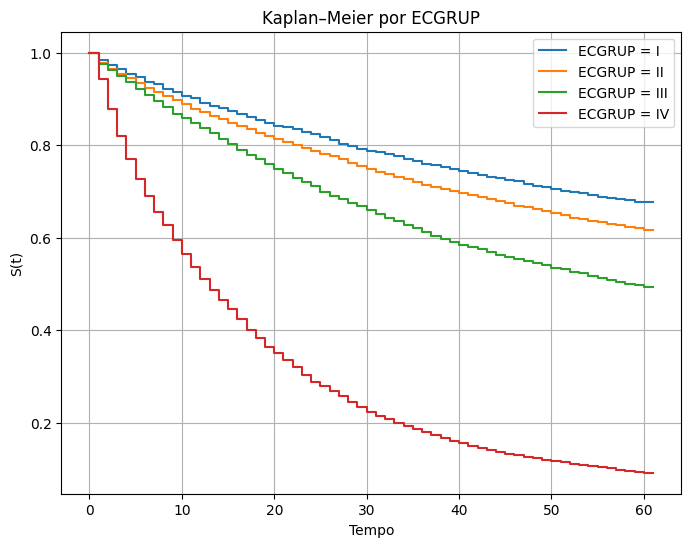

[KM] Log-rank global para ECGRUP: chi2 = 10907.81, p = 0



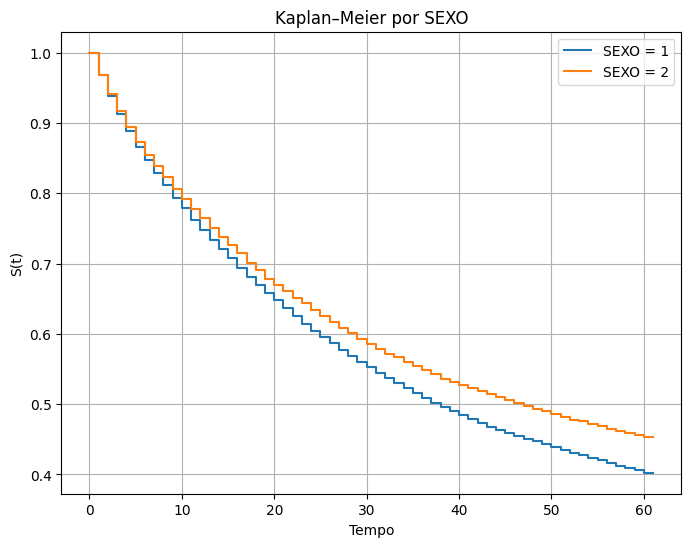

[KM] Log-rank global para SEXO: chi2 = 71.36, p = 2.982e-17



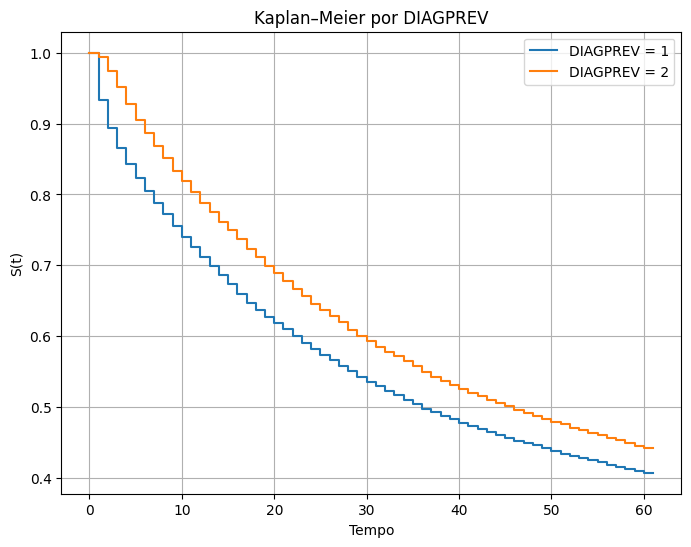

[KM] Log-rank global para DIAGPREV: chi2 = 113.79, p = 1.449e-26



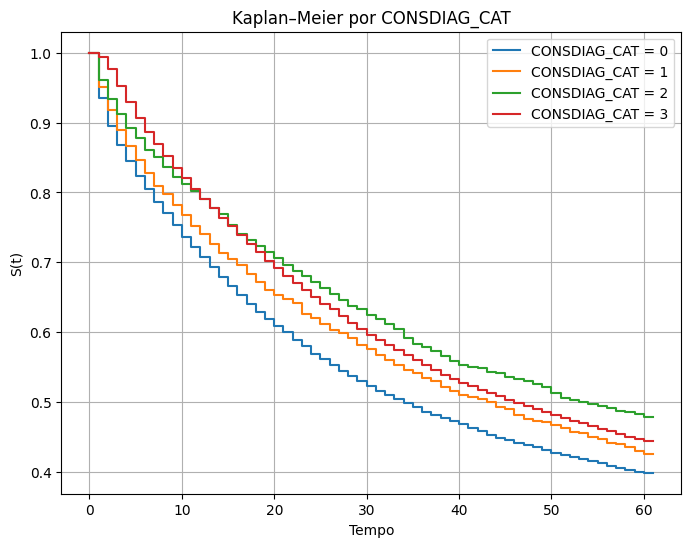

[KM] Log-rank global para CONSDIAG_CAT: chi2 = 166.72, p = 6.51e-36



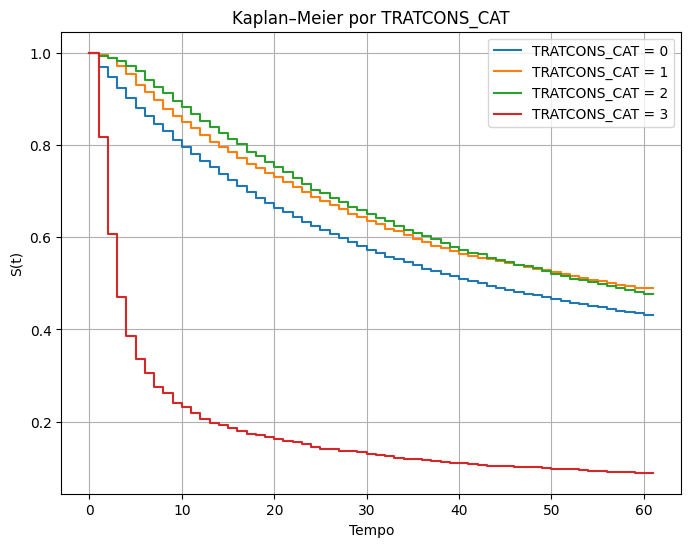

[KM] Log-rank global para TRATCONS_CAT: chi2 = 4311.62, p = 0



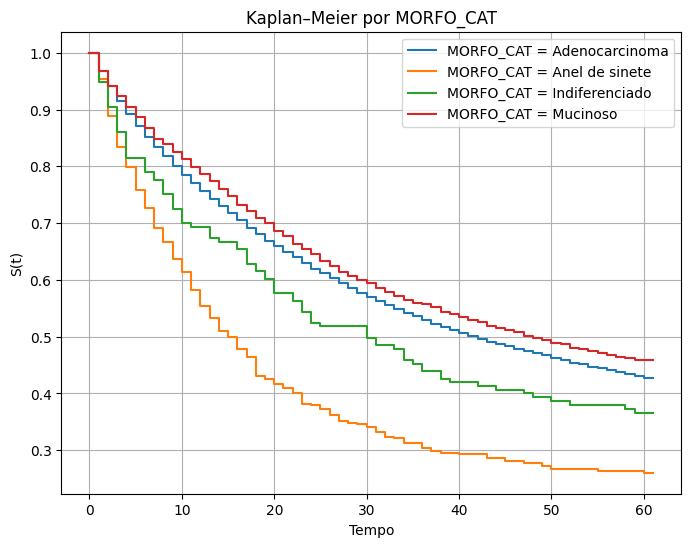

[KM] Log-rank global para MORFO_CAT: chi2 = 103.52, p = 2.718e-22



In [ ]:
# Lista de variáveis categóricas para análise exploratória - APENAS NO CONJUNTO DE TREINAMENTO
grupos_km = [
    'ECGRUP',          # Estadiamento clínico
    'SEXO',            # Sexo
    'DIAGPREV',        # Diagnóstico prévio
    'CONSDIAG_CAT',    # Tempo consulta–diagnóstico (categorizado)
    'TRATCONS_CAT',    # Tempo tratamento–consulta (categorizado)
    'MORFO_CAT'        # Morfologia tumoral
]

# Aplicação da análise Kaplan–Meier + Log-rank - APENAS NO TREINAMENTO
print("="*80)
print("ANÁLISE EXPLORATÓRIA: CURVAS KAPLAN-MEIER (Conjunto de Treinamento)")
print("="*80 + "\n")

for col in grupos_km:
    if col in X_train.columns:
        km_by_group(
            df = X_train,                     # DataFrame SEM codificação - APENAS TREINAMENTO
            time_col = 'time',                # Tempo de sobrevivência (em meses)
            event_col = 'event',              # Evento (1 = óbito, 0 = censura)
            group_col = col,                  # Variável categórica analisada
            title = f"[TREINO] Kaplan–Meier por {col}" # Título
        )

### <font color = FFB90F>**Log(Log(X(t))))**

In [ ]:
# Função Gráfica
def loglog_plot_by_group(df, time_col, event_col, group_col, title = None):
    """
    Descrição:
      Plota o gráfico log(-log(S(t))) vs log(tempo) para cada nível (categoria) de `group_col`.
      Esse gráfico é um diagnóstico VISUAL da suposição de Proportional Hazards (PH).

      Interpretação:
        - Se as curvas dos grupos ficarem aproximadamente PARALELAS, isso sugere PH ok para esse fator.
        - Se cruzarem muito, abrirem/fecharem fortemente ou tiverem formatos muito diferentes,
          pode indicar violação de PH.

    Parâmetros:
      df (pd.DataFrame): DataFrame contendo as colunas de tempo, evento e a coluna categórica `group_col`.
      time_col (str): nome da coluna de tempo (ex.: "time").
      event_col (str): nome da coluna de evento (1 = evento, 0 = censura) (ex.: "event").
      group_col (str): nome da coluna categórica para separar em grupos (ex.: "ECGRUP").
      title (str | None): título opcional do gráfico.

    Retorno:
      None (A função apenas plota e imprime resultados)
    """

    # Cria o estimador de Kaplan-Meier (não-paramétrico)
    kmf = KaplanMeierFitter()

    # Abre uma figura nova para o gráfico
    plt.figure(figsize = (8, 6))

    # Agrupa o dataset por cada categoria do group_col
    for level, sub in df.groupby(group_col):
        kmf.fit(
            durations = sub[time_col],        # coluna de tempo
            event_observed = sub[event_col],  # coluna de evento
            label = f"{group_col} = {level}"    # variáveis analisadas
        )

        # Pega a curva de sobrevivência S(t) estimada pelo KM
        #   kmf.survival_function_ é um DataFrame com índice = tempos e 1 coluna (a curva)
        sf = kmf.survival_function_.iloc[:, 0]

        # Proteções numéricas:
        # - S(t) pode chegar a 0 em tempos tardios -> log(0) é inválido
        # - tempo pode ter 0 -> log(0) é inválido
        eps = 1e-10
        s = sf.clip(lower = eps)                          # evita S(t) = 0
        t = sf.index.to_numpy().clip(min = eps)           # evita tempo = 0

        # Transformações do gráfico:
        # y = log(-log(S(t)))
        # x = log(t)
        y = np.log(-np.log(s.to_numpy()))
        x = np.log(t)

        # Plota a curva transformada para esse grupo
        plt.plot(x, y, label = f"{group_col} = {level}")

    # Título específico ou título padrão
    plt.title(title or f"log(-log(S(t))) vs log(tempo) por {group_col}")

    # Eixos
    plt.xlabel("log(tempo)")
    plt.ylabel("log(-log(S(t)))")

    plt.legend()    # Legenda
    plt.grid(True)  # Quadriculado
    plt.show()      # Exibição


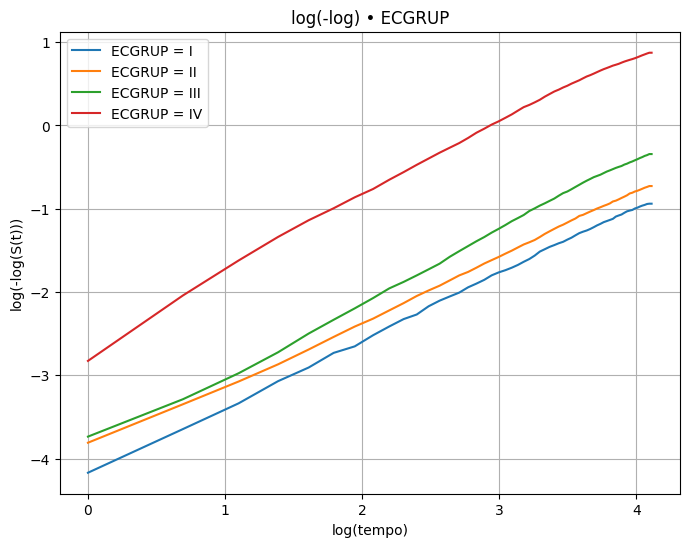

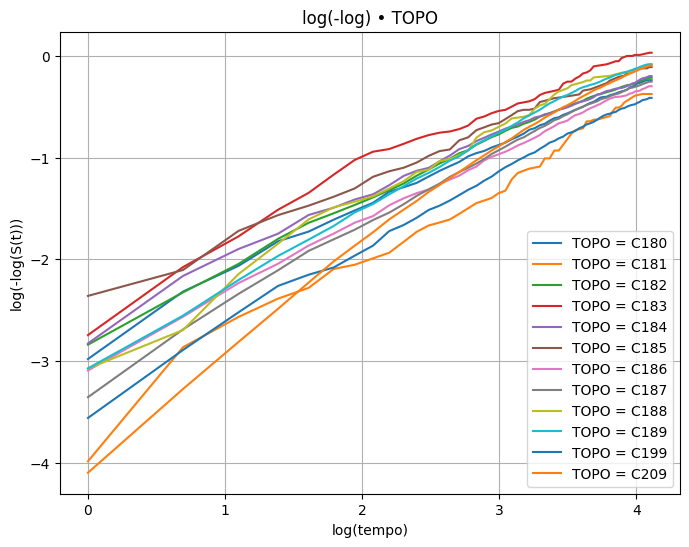

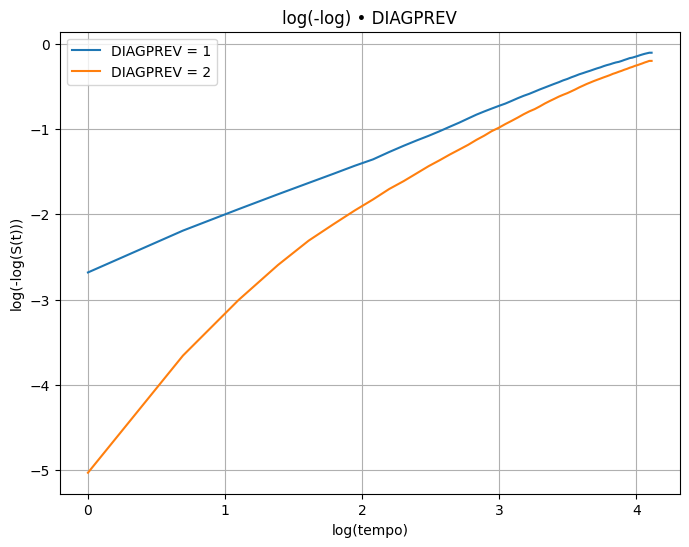

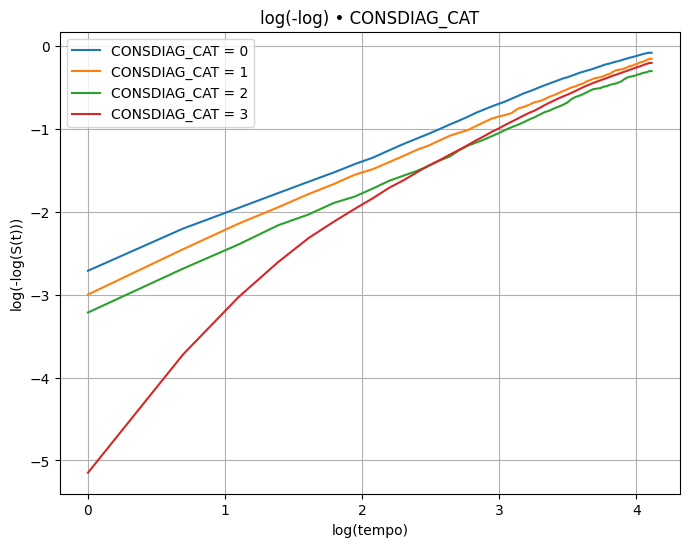

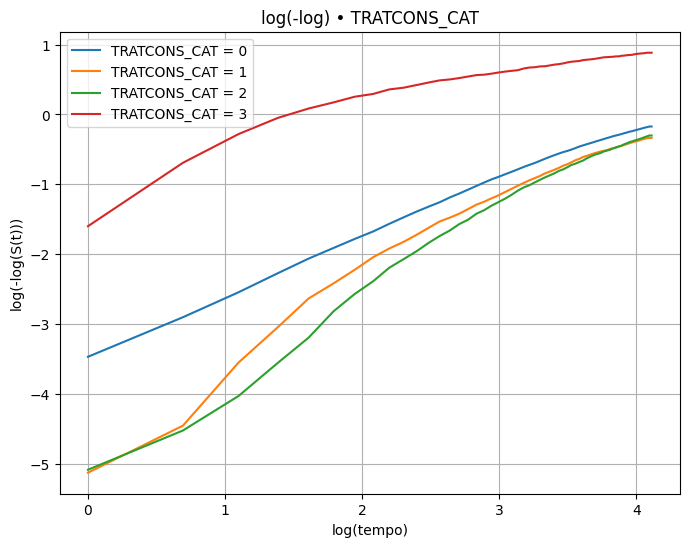

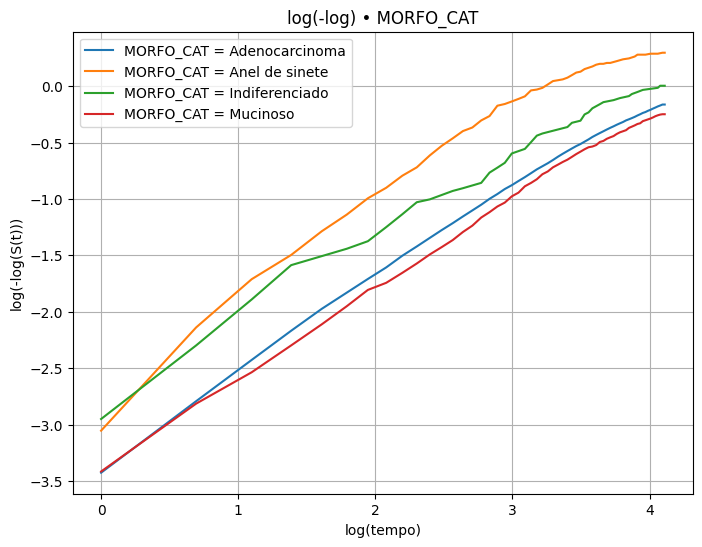

In [ ]:
# Lista de variáveis categóricas para análise exploratória - APENAS NO CONJUNTO DE TREINAMENTO
cats_to_check = [
    'ECGRUP',          # Estadiamento clínico
    'TOPO',            # Topografia
    'DIAGPREV',        # Diagnóstico prévio
    'CONSDIAG_CAT',    # Tempo consulta–diagnóstico (categorizado)
    'TRATCONS_CAT',    # Tempo tratamento–consulta (categorizado)
    'MORFO_CAT'        # Morfologia tumoral
]

print("="*80)
print("ANÁLISE DE PROPORCIONALIDADE: Log-Log Plots (Conjunto de Treinamento)")
print("="*80 + "\n")

for col in cats_to_check:
    if col in X_train.columns:
        loglog_plot_by_group(
            df = X_train,                     # DataFrame SEM codificação - APENAS TREINAMENTO
            time_col = 'time',                # Tempo de sobrevivência (em meses)
            event_col = 'event',              # Evento (1 = óbito, 0 = censura)
            group_col = col,                  # Variável categórica analisada
            title = f"[TREINO] log(-log) • {col}"      # Título
        )

### <font color = FFB90F>**Resíduos de Martingale**

In [ ]:
def martingale(cph, df, cont_col, time_col = 'time', event_col = 'event'):
    """
    Descrição:
      Avalia se a relação entre uma variável contínua (`cont_col`) e o log-hazard
      é aproximadamente linear, como assumido pelo modelo de Cox padrão.

      O diagnóstico é feito por meio dos resíduos de Martingale:
        - Se os resíduos estiverem distribuídos aleatoriamente ao redor de 0,
          a suposição de linearidade é plausível.
        - Se houver padrão curvo (U, ∩, tendência crescente/decrescente),
          isso sugere que a variável NÃO entra de forma linear no log-hazard.

    Parâmetros:
      cph : lifelines.CoxPHFitter
        Modelo Cox já ajustado.
      df : pandas.DataFrame
        DataFrame usado no fit (ou equivalente), contendo `cont_col`, `time` e `event`.
      cont_col : str
        Nome da variável contínua a ser avaliada (ex.: "IDADE").
      time_col : str
        Nome da coluna de tempo (def = ult = "time").
      event_col : str
        Nome da coluna de evento (d = fault = "event").

    Retorno:
        (Apenas exibe o gráfico diagnóstico)
    """

    # Calcula os resíduos de Martingale para cada observação (eles medem a diferença entre eventos observados e esperados)
    res_mart = cph.compute_residuals(df, kind='martingale')
    residual_values = res_mart.iloc[:, 0].values  # pega a única coluna de resíduos

    # Cria a figura
    plt.figure(figsize = (7, 5))

    # Scatter plot
    plt.scatter(
        x = df[cont_col],         # eixo x: variável co = tínua
        y = residual_values,      # eixo y: resíduos de Martingale
        s = 5,                  # tamanho do marcador
        alpha = 0.3             # transparência
    )

    # plt.scatter(
    #     df[cont_col],
    #     res_mart[event_col],
    #     s=5,
    #     alpha=0.3
    # )

    # Ajuste de uma curva suavizada (poli = ômio de grau 2)
    z = np.polyfit(df[cont_col], residual_values, 2)
    xp = np.linspace(df[cont_col].min(), df[cont_col].max(), 200)
    plt.plot(xp, np.polyval(z, xp))

    # Linha horizontal em y = 0 (referência)
    plt.axhline(0, ls = '--', lw = 1)

    # Título e rótulos
    plt.title(f"Resíduo de Martingale vs {cont_col}")
    plt.xlabel(cont_col)
    plt.ylabel("Martingale residual")

    # Quadriculado
    plt.grid(True)

    # Exibição
    plt.show()

C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


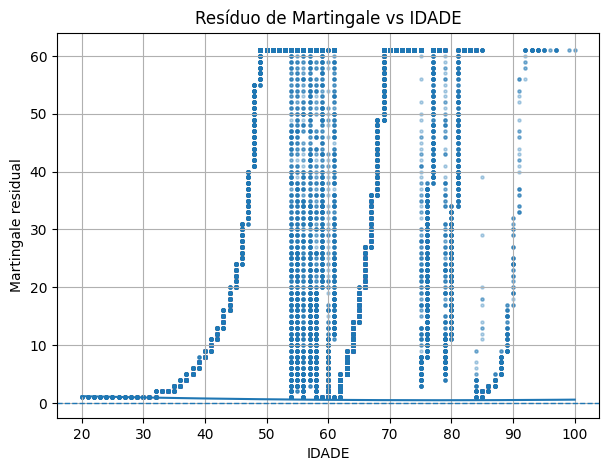

In [ ]:
# Aplicação do Teste de Linearidade - APENAS NO CONJUNTO DE TREINAMENTO
martingale(
    cph = cph,                  # Modelo de Cox ajustado COM dados de treinamento
    df = X_train_encoded,       # DataFrame TREINAMENTO codificado
    cont_col = "IDADE"          # Coluna contínua
)

## <font color = 56A5EC>**C-Índex**

In [ ]:
# Cálculo do índice de concordância para TREINO e TESTE
c_index_train = cph.score(X_train_encoded, scoring_method = 'concordance_index')
c_index_test = cph.score(X_test_encoded, scoring_method = 'concordance_index')

print('='*60)
print('CONCORDANCE INDEX (C-Index)')
print('='*60)
print(f'C-Index Treinamento: {c_index_train:.4f}')
print(f'C-Index Teste:       {c_index_test:.4f}')
print(f'Diferença:           {c_index_train - c_index_test:.4f}')
print('='*60)
print('\nInterpretação:')
print('  - C-Index = 0.5: Modelo aleatório')
print('  - C-Index = 1.0: Modelo perfeito')
print('  - Se (Treino - Teste) > 0.05: Possível overfitting')

C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


Concordance Index: 0.6983249347892989


## <font color = 56A5EC>**Predição**

In [ ]:
# Predição do tempo de sobrevivência esperado para TREINO e TESTE
y_pred_tempo_train = cph.predict_expectation(X_train_encoded)
y_pred_tempo_test = cph.predict_expectation(X_test_encoded)

# DataFrame com valores reais e previstos - TREINAMENTO
df_pred_tempo_train = pd.DataFrame({
    "Tempo de Sobrevida Real": X_train_encoded["time"],
    "Tempo de Sobrevida Previsto": y_pred_tempo_train
})

# DataFrame com valores reais e previstos - TESTE
df_pred_tempo_test = pd.DataFrame({
    "Tempo de Sobrevida Real": X_test_encoded["time"],
    "Tempo de Sobrevida Previsto": y_pred_tempo_test
})

print("PREDIÇÕES - CONJUNTO DE TREINAMENTO:")
display(df_pred_tempo_train.head(10))

print("\n" + "="*80 + "\n")

print("PREDIÇÕES - CONJUNTO DE TESTE:")
display(df_pred_tempo_test.head(10))

PREDIÇÕES - CONJUNTO DE TREINAMENTO:


,Tempo de Sobrevida Real,Tempo de Sobrevida Previsto
0,2,50.057938
1,15,40.347946
2,19,20.847132
3,61,47.292737
4,61,32.287023
5,45,42.400606
6,6,32.962507
7,61,35.114306
8,21,12.529467
9,61,43.005961




PREDIÇÕES - CONJUNTO DE TESTE:


,Tempo de Sobrevida Real,Tempo de Sobrevida Previsto
0,1,40.961496
1,23,50.527743
2,35,53.092257
3,13,19.533003
4,10,19.010203
5,6,29.060447
6,31,36.070276
7,10,33.960618
8,35,27.087871
9,61,26.362956


In [ ]:
# Estatísticas básicas das previsões - TREINAMENTO
print("ESTATÍSTICAS DAS PREVISÕES - TREINAMENTO:")
print(f"  Tempo previsto mínimo: {y_pred_tempo_train.min():.4f} meses")
print(f"  Tempo previsto máximo: {y_pred_tempo_train.max():.4f} meses")
print(f"  Tempo previsto médio:  {y_pred_tempo_train.mean():.4f} meses")

print("\nESTATÍSTICAS DAS PREVISÕES - TESTE:")
print(f"  Tempo previsto mínimo: {y_pred_tempo_test.min():.4f} meses")
print(f"  Tempo previsto máximo: {y_pred_tempo_test.max():.4f} meses")
print(f"  Tempo previsto médio:  {y_pred_tempo_test.mean():.4f} meses")

Valor mínimo do tempo previsto (Original): 0.8349
Valor máximo do tempo previsto (Original): 57.9661


In [ ]:
# Diferença entre tempo real e previsto - TREINAMENTO
diferenca_tempo_train = X_train_encoded["time"] - y_pred_tempo_train
print("RESÍDUOS (Real - Previsto) - TREINAMENTO:")
print(f"  Mínimo:  {diferenca_tempo_train.min():.4f}")
print(f"  Máximo:  {diferenca_tempo_train.max():.4f}")
print(f"  Média:   {diferenca_tempo_train.mean():.4f}")
print(f"  Mediana: {diferenca_tempo_train.median():.4f}")

print("\n" + "="*60 + "\n")

# Diferença entre tempo real e previsto - TESTE
diferenca_tempo_test = X_test_encoded["time"] - y_pred_tempo_test
print("RESÍDUOS (Real - Previsto) - TESTE:")
print(f"  Mínimo:  {diferenca_tempo_test.min():.4f}")
print(f"  Máximo:  {diferenca_tempo_test.max():.4f}")
print(f"  Média:   {diferenca_tempo_test.mean():.4f}")
print(f"  Mediana: {diferenca_tempo_test.median():.4f}")

RESÍDUOS (Real - Previsto) - TREINAMENTO:
  Mínimo:  -55.0869
  Máximo:  58.9318
  Média:   -0.4918
  Mediana: 2.2232


RESÍDUOS (Real - Previsto) - TESTE:
  Mínimo:  -54.5374
  Máximo:  57.5121
  Média:   -0.4196
  Mediana: 2.1444


## <font color = 56A5EC>**Métricas de Erro**

In [ ]:
def ibs(cph_model, X, time_col="time", event_col="event", t0=60):
    """
    Descrição:
      Calcula o IBS (Integrated Brier Score) para um modelo Cox ajustado.

    Parâmetros:
      cph_model : lifelines.CoxPHFitter
          Modelo Cox já ajustado.

      X : pd.DataFrame
          DataFrame com as covariáveis e as colunas de tempo e evento.

      time_col : str, default="time"
          Nome da coluna de tempo.

      event_col : str, default="event"
          Nome da coluna de evento.

      t0 : int, default=60
          Horizonte máximo de tempo para o cálculo do IBS.

    Retorno:
      float
          Valor do IBS.
    """

    # Estrutura de sobrevivência no formato do scikit-survival
    y = Surv.from_dataframe(event_col, time_col, X)

    # Grade de tempos até o horizonte máximo
    times = np.arange(1, min(t0, int(X[time_col].max())) + 1)

    # Curvas de sobrevivência previstas pelo modelo
    sf = cph_model.predict_survival_function(X)

    # Ajusta as curvas para a grade temporal escolhida
    sf = sf.reindex(times, method="pad").bfill()

    # Converte para o formato exigido pelo integrated_brier_score
    surv_matrix = sf.T.values

    # Calcula o IBS
    score = integrated_brier_score(y, y, surv_matrix, times)

    return float(score)

In [ ]:
def c_index_ipcw_cox(cph_model, X, time_col = "time", event_col = "event", tau = None):
    """
    Descrição:
      Calcula o C-Index IPCW para um modelo Cox ajustado.

      O IPCW (Inverse Probability of Censoring Weighting) ajusta o índice
      de concordância para a presença de censura, tornando a avaliação
      mais apropriada para dados de sobrevivência.

    Parâmetros:
      cph_model : lifelines.CoxPHFitter
          Modelo Cox já ajustado.

      X : pd.DataFrame
          DataFrame com as covariáveis e as colunas de tempo e evento.

      time_col : str, default="time"
          Nome da coluna de tempo.

      event_col : str, default="event"
          Nome da coluna de evento.

      tau : float or None, default=None
          Horizonte máximo considerado no cálculo.
          Se None, usa o maior tempo observado no conjunto.

    Retorno:
      float
          Valor do C-Index IPCW.
    """

    # Estrutura de sobrevivência no formato do scikit-survival
    y = Surv.from_dataframe(event_col, time_col, X)

    # Escore de risco previsto pelo modelo
    risk_scores = cph_model.predict_partial_hazard(X).values.ravel()

    # Horizonte máximo de tempo para o cálculo
    if tau is None:
        tau = X[time_col].max()

    # Calcula o C-Index IPCW
    c_ipcw = concordance_index_ipcw(y, y, risk_scores, tau = tau)[0]

    return float(c_ipcw)

In [ ]:
def cox_metrics_original(
    cph_model, X,
    time_col = "time",
    event_col = "event",
    t0 = 60
):
    """
    Descrição:
      Calcula métricas para o modelo de Cox original.

    Métricas principais:
      - C-Index
      - C-Index IPCW
      - IBS

    Métricas complementares:
      - MSE
      - RMSE
      - MAE

    Parâmetros:
      cph_model : lifelines.CoxPHFitter
          Modelo Cox ajustado.

      X : pd.DataFrame
          DataFrame com as covariáveis e as colunas de tempo e evento.

      time_col : str, default="time"
          Nome da coluna de tempo.

      event_col : str, default="event"
          Nome da coluna de evento.

      t0 : int, default=60
          Horizonte máximo para o cálculo do IBS e do C-Index IPCW.

    Retorno:
      pd.DataFrame
          Tabela com as métricas do modelo.
    """

    # Previsões do tempo esperado de sobrevivência
    pred = cph_model.predict_expectation(X)

    # Métricas
    metrics = {
        "C-Index": float(cph_model.score(X, scoring_method = "concordance_index")),
        "C-Index IPCW": c_index_ipcw_cox(cph_model, X, time_col = time_col, event_col = event_col, tau = t0),
        "IBS": ibs(cph_model, X, time_col = time_col, event_col = event_col, t0 = t0),
        "MSE": float(mean_squared_error(X[time_col], pred)),
        "RMSE": float(np.sqrt(mean_squared_error(X[time_col], pred))),
        "MAE": float(mean_absolute_error(X[time_col], pred))
    }

    # Tabela final
    df_metrics = pd.DataFrame({
        "Resultados": metrics
    })

    df_metrics.index.name = "Métricas"

    display(df_metrics)
    return df_metrics

In [ ]:
# Cálculo de métricas para TREINAMENTO e TESTE
print("="*80)
print("MÉTRICAS DE DESEMPENHO - CONJUNTO DE TREINAMENTO")
print("="*80)
df_metrics_train = cox_metrics_original(
    cph_model = cph,
    X = X_train_encoded,
    t0 = 60
)

print("\n" + "="*80)
print("MÉTRICAS DE DESEMPENHO - CONJUNTO DE TESTE")
print("="*80)
df_metrics_test = cox_metrics_original(
    cph_model = cph,
    X = X_test_encoded,
    t0 = 60
)

# Comparação lado a lado
print("\n" + "="*80)
print("COMPARAÇÃO: TREINAMENTO vs TESTE")
print("="*80)
df_comparison = pd.DataFrame({
    "Treinamento": df_metrics_train["Resultados"],
    "Teste": df_metrics_test["Resultados"],
    "Diferença": df_metrics_train["Resultados"] - df_metrics_test["Resultados"]
})
display(df_comparison)

MÉTRICAS DE DESEMPENHO - CONJUNTO DE TREINAMENTO


C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


,Resultados
Métricas,
C-Index,0.697613
C-Index IPCW,0.697102
IBS,0.266063
MSE,410.424210
RMSE,20.258929
MAE,17.115990



MÉTRICAS DE DESEMPENHO - CONJUNTO DE TESTE (Avaliação Honesta)


C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


,Resultados
Métricas,
C-Index,0.698561
C-Index IPCW,0.697857
IBS,0.266394
MSE,412.931811
RMSE,20.320724
MAE,17.086289



COMPARAÇÃO: TREINAMENTO vs TESTE


,Treinamento,Teste,Diferença
Métricas,,,
C-Index,0.697613,0.698561,-0.000948
C-Index IPCW,0.697102,0.697857,-0.000755
IBS,0.266063,0.266394,-0.000331
MSE,410.424210,412.931811,-2.507601
RMSE,20.258929,20.320724,-0.061795
MAE,17.115990,17.086289,0.029701


## <font color = 56A5EC>**Gráficos**

### <font color = FFB90F>**Modelo Original: Tempo Real vs Previsto**

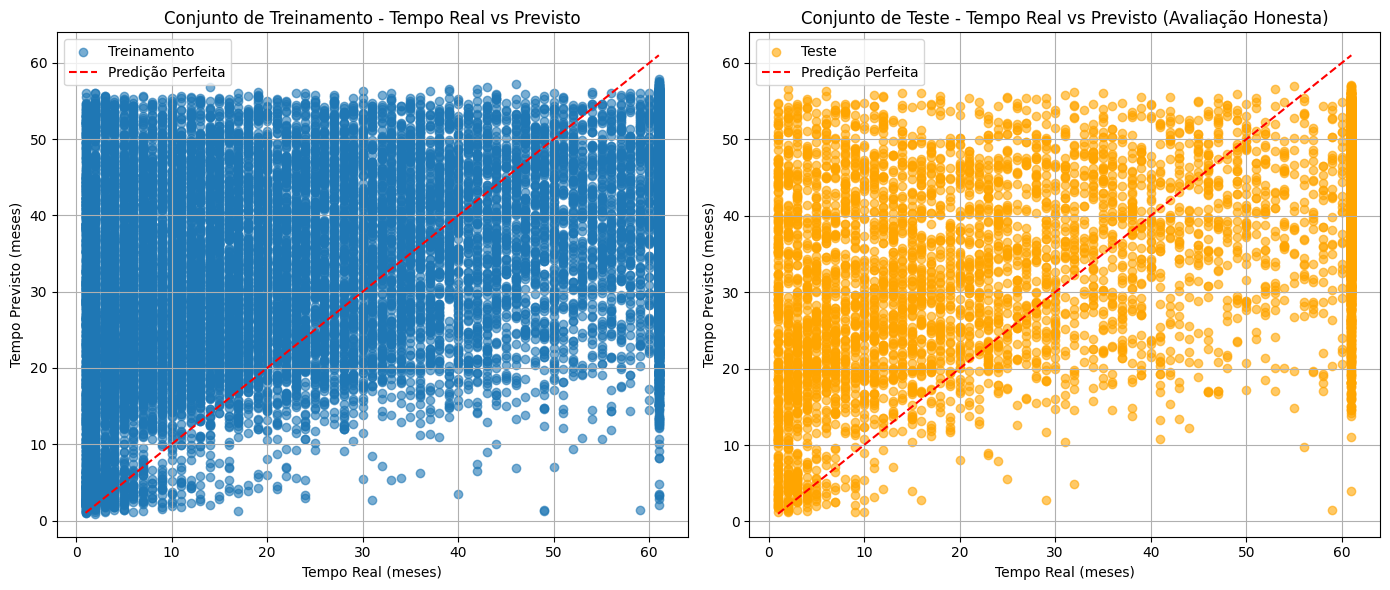

In [ ]:
plt.figure(figsize = (14, 6))

# TREINAMENTO
plt.subplot(1, 2, 1)
plt.scatter(X_train_encoded["time"], y_pred_tempo_train, alpha = 0.6, label="Treinamento")
plt.plot(
    [X_train_encoded["time"].min(), X_train_encoded["time"].max()],
    [X_train_encoded["time"].min(), X_train_encoded["time"].max()],
    color = "red",
    linestyle = "--",
    label="Predição Perfeita"
)
plt.xlabel("Tempo Real (meses)")
plt.ylabel("Tempo Previsto (meses)")
plt.title("Conjunto de Treinamento - Tempo Real vs Previsto")
plt.legend()
plt.grid(True)

# TESTE
plt.subplot(1, 2, 2)
plt.scatter(X_test_encoded["time"], y_pred_tempo_test, alpha = 0.6, color="orange", label="Teste")
plt.plot(
    [X_test_encoded["time"].min(), X_test_encoded["time"].max()],
    [X_test_encoded["time"].min(), X_test_encoded["time"].max()],
    color = "red",
    linestyle = "--",
    label="Predição Perfeita"
)
plt.xlabel("Tempo Real (meses)")
plt.ylabel("Tempo Previsto (meses)")
plt.title("Conjunto de Teste - Tempo Real vs Previsto (Avaliação Honesta)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### <font color = FFB90F>**Distribuição dos Resíduos**

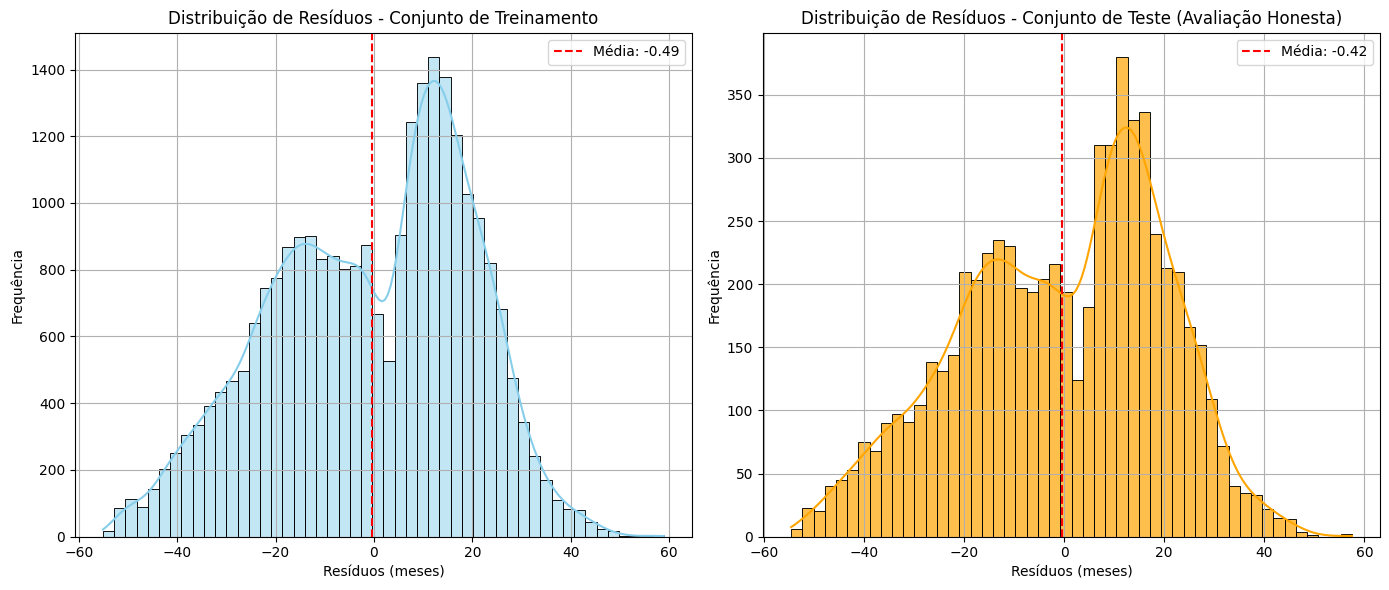

In [ ]:
plt.figure(figsize = (14, 6))

# TREINAMENTO
plt.subplot(1, 2, 1)
sns.histplot(diferenca_tempo_train, kde = True, bins=50, color="skyblue")
plt.axvline(diferenca_tempo_train.mean(), color="red", linestyle="--", label=f"Média: {diferenca_tempo_train.mean():.2f}")
plt.xlabel("Resíduos (meses)")
plt.ylabel("Frequência")
plt.title("Distribuição de Resíduos - Conjunto de Treinamento")
plt.legend()
plt.grid(True)

# TESTE
plt.subplot(1, 2, 2)
sns.histplot(diferenca_tempo_test, kde = True, bins=50, color="orange", alpha=0.7)
plt.axvline(diferenca_tempo_test.mean(), color="red", linestyle="--", label=f"Média: {diferenca_tempo_test.mean():.2f}")
plt.xlabel("Resíduos (meses)")
plt.ylabel("Frequência")
plt.title("Distribuição de Resíduos - Conjunto de Teste (Avaliação Honesta)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### <font color = FFB90F>**Curva de Kaplan-Meier Geral**

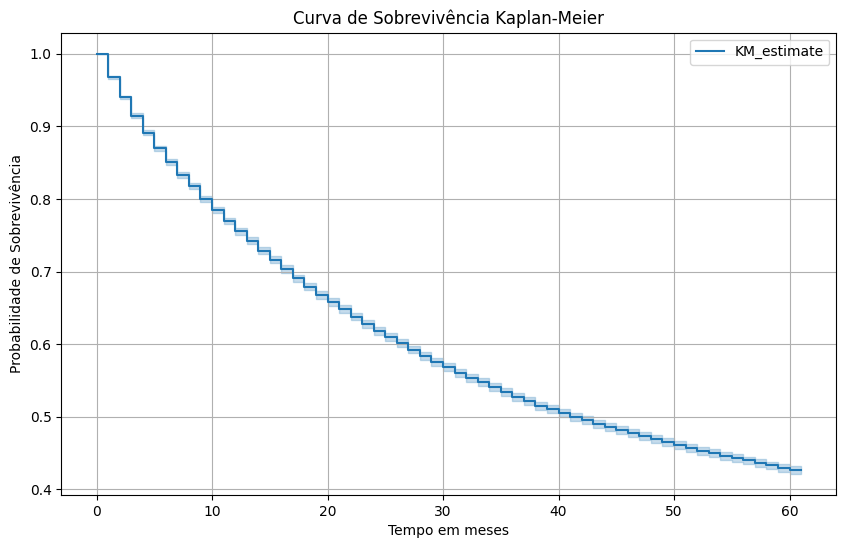

In [ ]:
kmf = KaplanMeierFitter()

plt.figure(figsize = (14, 6))

# TREINAMENTO
plt.subplot(1, 2, 1)
kmf.fit(X_train_encoded["time"], X_train_encoded["event"], label="Treinamento")
kmf.plot_survival_function()
plt.title("Curva Kaplan-Meier - Conjunto de Treinamento")
plt.xlabel("Tempo (meses)")
plt.ylabel("Probabilidade de Sobrevivência")
plt.grid(True)

# TESTE
plt.subplot(1, 2, 2)
kmf.fit(X_test_encoded["time"], X_test_encoded["event"], label="Teste")
kmf.plot_survival_function(color="orange")
plt.title("Curva Kaplan-Meier - Conjunto de Teste")
plt.xlabel("Tempo (meses)")
plt.ylabel("Probabilidade de Sobrevivência")
plt.grid(True)

plt.tight_layout()
plt.show()

### <font color = FFB90F>**Distribuição do Tempo de Sobrevida**

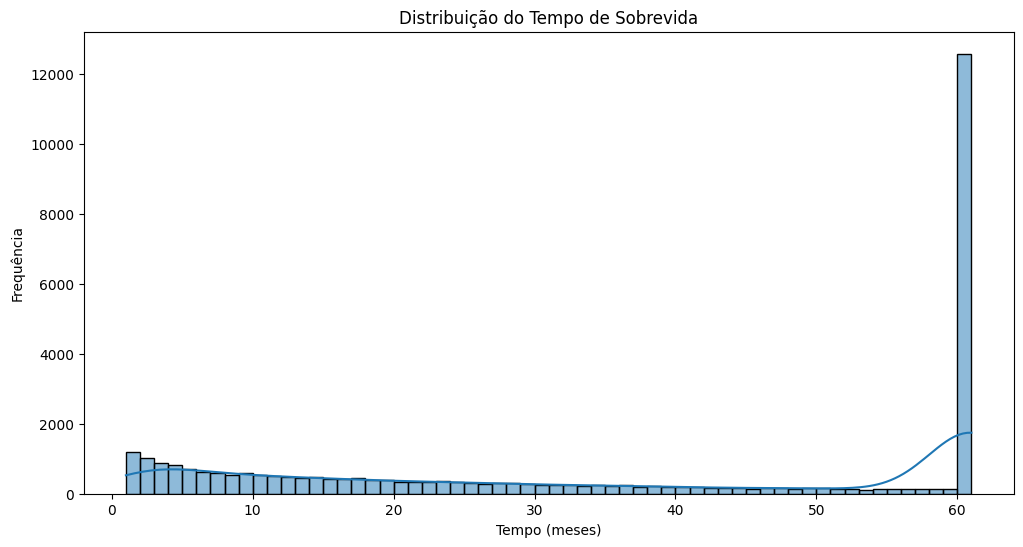

In [ ]:
plt.figure(figsize = (14, 6))

# TREINAMENTO
plt.subplot(1, 2, 1)
sns.histplot(X_train_encoded["time"], bins = 60, edgecolor = "k", kde = True, color="skyblue")
plt.title("Distribuição do Tempo de Sobrevida - Conjunto de Treinamento")
plt.xlabel("Tempo (meses)")
plt.ylabel("Frequência")
plt.grid(True)

# TESTE
plt.subplot(1, 2, 2)
sns.histplot(X_test_encoded["time"], bins = 30, edgecolor = "k", kde = True, color="orange", alpha=0.7)
plt.title("Distribuição do Tempo de Sobrevida - Conjunto de Teste")
plt.xlabel("Tempo (meses)")
plt.ylabel("Frequência")
plt.grid(True)

plt.tight_layout()
plt.show()